In [1]:
!pip install pyro-ppl

   ---------------------------------------- 0.0/756.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/756.0 kB ? eta -:--:--
   ---- ----------------------------------- 81.9/756.0 kB 1.5 MB/s eta 0:00:01
   ------ --------------------------------- 122.9/756.0 kB 1.8 MB/s eta 0:00:01
   ------------- -------------------------- 245.8/756.0 kB 2.1 MB/s eta 0:00:01
   ------------------- -------------------- 368.6/756.0 kB 2.3 MB/s eta 0:00:01
   ----------------------------- ---------- 553.0/756.0 kB 2.5 MB/s eta 0:00:01
   ----------------------------- ---------- 553.0/756.0 kB 2.5 MB/s eta 0:00:01
   ---------------------------------------- 756.0/756.0 kB 2.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/71.9 kB ? eta -:--:--
   ---------------------------------------- 71.9/71.9 kB ? eta 0:00:00



[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import torch
import pyro
import pyro.distributions as dist
from pyro.infer import SVI, Trace_ELBO, MCMC, NUTS, Predictive
from pyro.infer.autoguide import AutoDiagonalNormal, AutoMultivariateNormal, init_to_median
from pyro.optim import Adam
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import numpy as np
from sklearn.cluster import KMeans
import time
import warnings
warnings.filterwarnings('ignore')

Генерация данных и вспомогательная функция для эллипсов

Кластер A – широкий, изотропный, легко моделируемый диагональной ковариацией.

Кластер B – сильно вытянутый и повёрнутый, требует полной матрицы ковариации для адекватного описания.

Кластер C – очень узкий пик, вложен в область кластера B, что создаёт трудности для моделей, которые переоценивают неопределённость.

In [ ]:
def generate_complex_gmm_data_with_labels(n_samples=1500):
    torch.manual_seed(42)
    loc_a = torch.tensor([7.5, 2.5])
    data_a = torch.randn(600, 2) * 1.8 + loc_a

    loc_b = torch.tensor([5.0, 5.0])
    scale_b = torch.tensor([4.5, 0.6])
    theta = torch.tensor([torch.pi / 4])
    rot = torch.tensor([[theta.cos(), -theta.sin()], [theta.sin(), theta.cos()]])
    data_b = (torch.randn(600, 2) * scale_b) @ rot.T + loc_b

    loc_c = torch.tensor([3.5, 5.5])
    data_c = torch.randn(300, 2) * 0.2 + loc_c

    data = torch.cat([data_a, data_b, data_c])
    labels = torch.cat([torch.zeros(600), torch.ones(600), torch.ones(300)*2])
    idx = torch.randperm(n_samples)
    return data[idx], labels[idx]

data_2d, true_labels = generate_complex_gmm_data_with_labels()


# Рисует эллипс рассеяния (2-sigma) для двумерного распределения
def plot_ellipses(ax, mean, cov, color='red', alpha=0.3, n_std=2.0):
    
    if cov.ndim == 1:
        cov = torch.diag(cov)
    cov_np = cov.detach().numpy()
    mean_np = mean.detach().numpy()
    eigenvalues, eigenvectors = np.linalg.eigh(cov_np)
    order = eigenvalues.argsort()[::-1]
    eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]
    angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(eigenvalues)
    ell = Ellipse(xy=mean_np, width=width, height=height, angle=angle,
                  edgecolor=color, fc=color, alpha=alpha, lw=2)
    ax.add_patch(ell)

Модели (Mean‑Field и Full‑Rank)

model_mf – смесь с диагональной ковариацией. Кластер получился круглым

model_fr – смесь с полной матрицей ковариации. Вместо прямого сэмплирования матрицы ковариации, использую разложение Холецкого (оно не требует доп. ограничений)

In [13]:
# Модель с диагональной ковариацией (Mean‑Field)
def model_mf(data, K=3):
    D = data.shape[1]
    weights = pyro.sample("weights", dist.Dirichlet(torch.ones(K)))
    with pyro.plate("components", K):
        locs = pyro.sample("locs", dist.Normal(torch.zeros(D), 1.0).to_event(1))
        scales = pyro.sample("scales", dist.LogNormal(torch.zeros(D), 1.0).to_event(1))
    mixing_dist = dist.Categorical(weights)
    component_dist = dist.Normal(locs, scales).to_event(1)
    mixture = dist.MixtureSameFamily(mixing_dist, component_dist)
    with pyro.plate("data", len(data)):
        pyro.sample("obs", mixture, obs=data)

# Модель с полной ковариацией (Full‑Rank, LKJ)
def model_fr(data, K=3):
    D = data.shape[1]
    weights = pyro.sample("weights", dist.Dirichlet(torch.ones(K)))
    with pyro.plate("components", K):
        locs = pyro.sample("locs", dist.Normal(torch.zeros(D), 10.0).to_event(1))
        scales = pyro.sample("scales", dist.LogNormal(torch.zeros(D), 2.0).to_event(1)) + 0.01
        corr_cholesky = pyro.sample("corr_cholesky", dist.LKJCholesky(D, concentration=1.0))
        L = torch.matmul(torch.diag_embed(scales), corr_cholesky)
    with pyro.plate("data", len(data)):
        pyro.sample("obs", dist.MixtureSameFamily(
            dist.Categorical(weights),
            dist.MultivariateNormal(locs, scale_tril=L)
        ), obs=data)

Функции для обучения VI и извлечения параметров

Mean‑Field: guide.median() возвращает словарь параметров в ограниченном пространстве (веса уже на симплексе, шкалы положительные). Это прямое извлечение точечных оценок.

Full‑Rank: AutoMultivariateNormal параметризует многомерное нормальное распределение в неограниченном пространстве. Просто взять median() для компонентов модели сложно, так как параметры гида – это вектор всех переменных. Поэтому используется Predictive для генерации множества сэмплов параметров из guide, а затем усреднение (среднее апостериорное) для locs, а для ковариаций – усреднение по сэмплам

In [ ]:
def run_svi(model, guide, data, num_steps=2000, lr=0.01):
    pyro.clear_param_store()
    optimizer = Adam({"lr": lr})
    svi = SVI(model, guide, optimizer, loss=Trace_ELBO())
    losses = []
    start = time.time()
    for step in range(num_steps):
        loss = svi.step(data)
        losses.append(loss)
        if step % 500 == 0:
            print(f"Step {step}, ELBO: {loss:.2f}")
    print(f"VI finished in {time.time()-start:.2f} seconds")
    return svi, losses

def extract_params_mf(guide):
    # Извлечение параметров из Mean‑Field guide с помощью median()
    median = guide.median()
    return median['locs'], median['scales'], median['weights']

def extract_params_fr(guide, data, num_samples=500):
    # Извлечение параметров из Full‑Rank guide через семплирование и усреднение
    predictive = Predictive(model_fr, guide=guide, num_samples=num_samples,
                            return_sites=("locs", "scales", "corr_cholesky", "weights"))
    with torch.no_grad():
        samples = predictive(data)
    
    locs_mean = samples["locs"].mean(0)  # [K, D]
    scales_mean = samples["scales"].mean(0)  # [K, D]
    weights_mean = samples["weights"].mean(0)  # [K]
    
    K, D = locs_mean.shape
    covs = []
    for s in range(num_samples):
        L = torch.matmul(torch.diag_embed(samples["scales"][s]), samples["corr_cholesky"][s])
        cov = L @ L.transpose(-1, -2)  # [K, D, D]
        covs.append(cov)
    cov_mean = torch.stack(covs).mean(0)  # [K, D, D]
    return locs_mean, cov_mean, weights_mean

Раздел 1.1 – Mean‑Field VI


# a init_to_median
Кластер Синий: 
1) он СЛИШКОМ большой. 
2) Это плохо, много мусорныъ точек. 
3) Круглый - это хорошо
Кластер Красный: 
1) не очень маленький, что плохо, но круглый, что хорошою. 
2) Пересекается с синим - плохо. 
3) Наложен на зеленый - ВАЖНО И ПЛОХО!!! Это результат вложенности кластера C в область кластера B.
Кластер Зеленый: 
1) маленький - это плохо, круглый - тоже плохо. 
2) Содержит мало синих точек - плохо

Итог: Синий компонент не описывает кластер A. Он пытается компенсировать неспособность других компонентов описать свои кластеры, расширяясь.

# K‑means
Кластер Синий: 
1) Все еще большой, но уже не такой как был. 
2) K‑means его улучшил и он все еще круглый, что хорошо, но на взгляд 30% точек - зеленые и это плохо. 
3) Внутри него есть красный сгусток - вложенность сохранилось (проблема)
Кластер Красный: 
1) Маленький и круглый уже лучше. 
2) Но он ВНУТРИ синего - это проблема! 
Модель не может одновременно иметь:
    Большой синий для покрытия кластера A   
    Маленький красный внутри синего
Кластер Зеленый: 
1) стал больше но все еще недостаточно
2) 30% зелёных точек ВНЕ его (в синем)

Итог: Центры ближе к истине — K-means даёт хорошие стартовые позиции для средних
Эллипсы стали сбалансированнее
Красный компонент не исчез полностью, а описал узкий сгусток

Step 0, ELBO: 72605.22
Step 500, ELBO: 8945.06
Step 1000, ELBO: 8177.55
Step 1500, ELBO: 7646.40
VI finished in 15.89 seconds


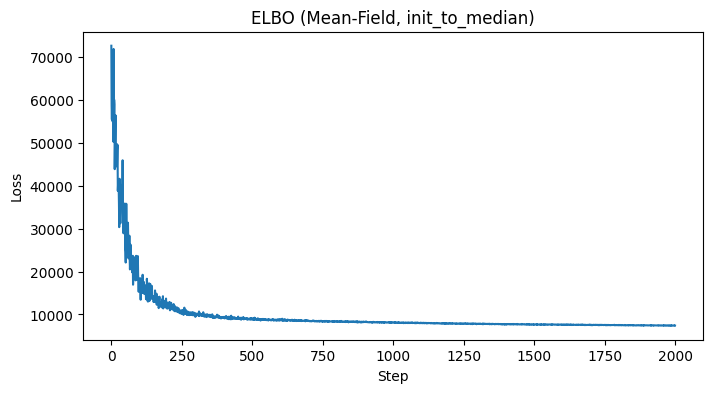

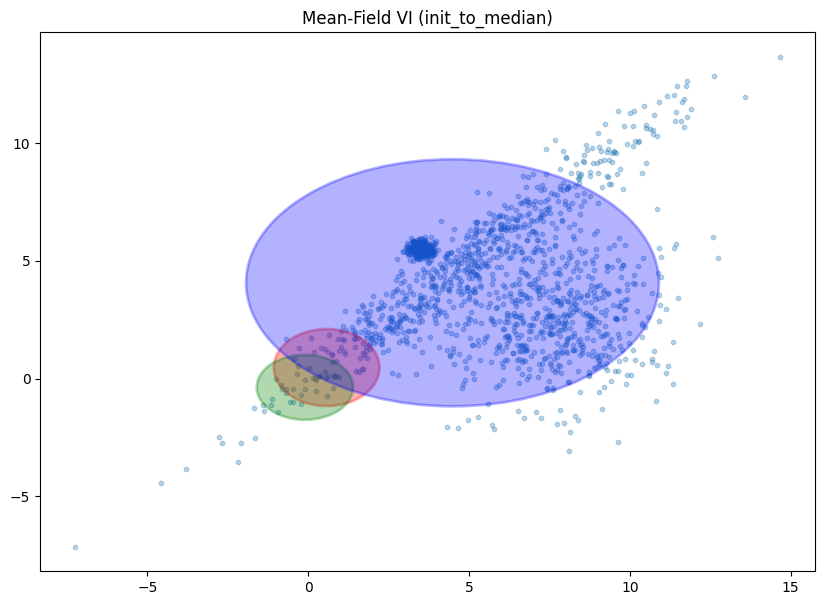

Step 0, ELBO: 13381.97
Step 500, ELBO: 6803.75
Step 1000, ELBO: 6525.64
Step 1500, ELBO: 6530.21
VI finished in 16.20 seconds


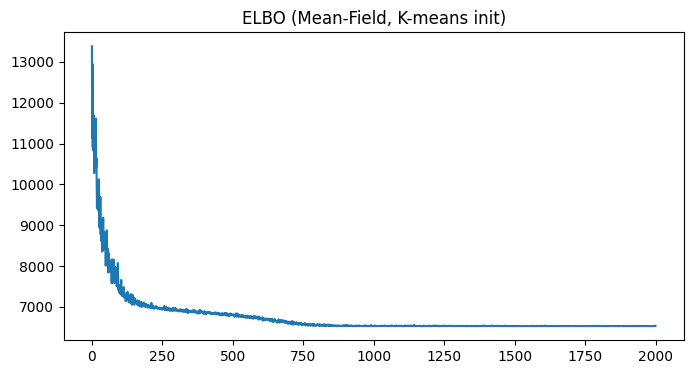

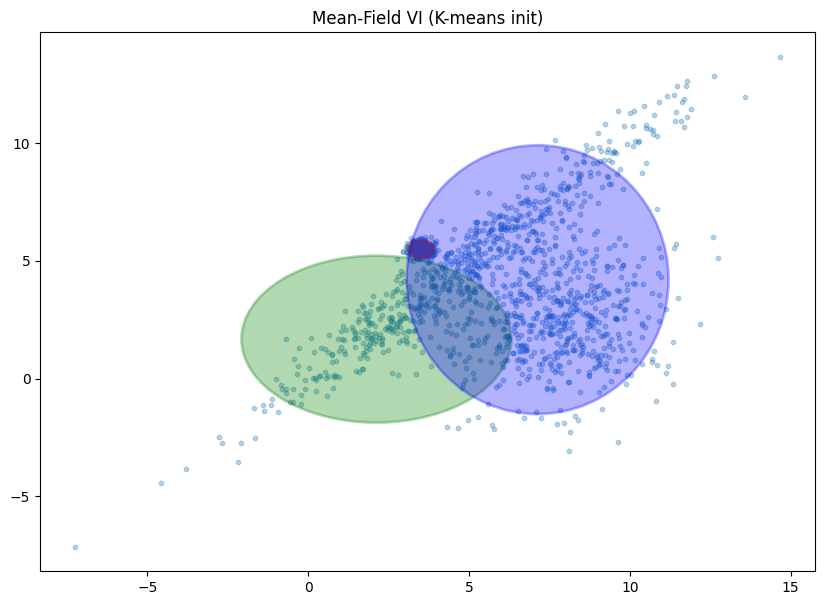

In [ ]:
K = 3
colors = ['red', 'green', 'blue']

# init_to_median 
guide_mf = AutoDiagonalNormal(pyro.poutine.block(model_mf, hide=["obs"]),
                              init_loc_fn=init_to_median)
svi_mf, loss_mf = run_svi(model_mf, guide_mf, data_2d)

plt.figure(figsize=(8,4))
plt.plot(loss_mf)
plt.title("ELBO (Mean-Field, init_to_median)")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.show()

locs_mf, scales_mf, w_mf = extract_params_mf(guide_mf)

plt.figure(figsize=(10,7))
plt.scatter(data_2d[:,0], data_2d[:,1], s=10, alpha=0.3)
for k in range(K):
    plot_ellipses(plt.gca(), locs_mf[k], scales_mf[k]**2, color=colors[k], alpha=0.3)
plt.title("Mean-Field VI (init_to_median)")
plt.show()

# K-means инициализация
def init_to_kmeans(site):
    if site["name"] == "locs":
        km = KMeans(n_clusters=K, random_state=42)
        km.fit(data_2d.numpy())
        return torch.tensor(km.cluster_centers_, dtype=torch.float32)
    return init_to_median(site)

guide_mf_km = AutoDiagonalNormal(pyro.poutine.block(model_mf, hide=["obs"]),
                                 init_loc_fn=init_to_kmeans)
svi_mf_km, loss_mf_km = run_svi(model_mf, guide_mf_km, data_2d)

plt.figure(figsize=(8,4))
plt.plot(loss_mf_km)
plt.title("ELBO (Mean-Field, K-means init)")
plt.show()

locs_mf_km, scales_mf_km, w_mf_km = extract_params_mf(guide_mf_km)

plt.figure(figsize=(10,7))
plt.scatter(data_2d[:,0], data_2d[:,1], s=10, alpha=0.3)
for k in range(K):
    plot_ellipses(plt.gca(), locs_mf_km[k], scales_mf_km[k]**2, color=colors[k], alpha=0.3)
plt.title("Mean-Field VI (K-means init)")
plt.show()

Раздел 1.2 – Full‑Rank VI

Теперь кластер B моделируется эллипсом, повёрнутым под 45°. Это соответствует данным и уменьшает ложное перекрытие. Кластер C выделяется отдельным узким эллипсом. Это показывает, что выбор более гибкого семейства (Full‑Rank) может сделать VI более точным.

# a init_to_median
Кластер Синий: 
1) Сильно вытянут - это плохо. 
3) Не Круглый - это плохо
Кластер Красный: 
1) не очень маленький, что плохо, но почти круглый, что хорошою. 
2) Пересекается с синим - плохо. 
3) Наложен на зеленый - ВАЖНО И ПЛОХО!!! Это результат вложенности кластера C в область кластера B.
Кластер Зеленый: 
1) Сильно вытянут - очень хорошо
2) Большой - хорошо
3) Немного съел другие кластеры - некретично

Итог: Зеленый почти идеален, но у других все еще есть проблемы 

# K‑means
Кластер Синий: 
1) Идеальный круг 
2) Средний размер
3) Почти все синие точки
Кластер Красный: 
1) Оченнь маленький 
2) Круглый
3) На сгустке
Не исчез (как в Mean-Field)
Не расплылся (как в Full-Rank с median)
Не потерял свои точки
Чётко описывает узкий пик кластера 
Кластер Зеленый: 
1) Сильно вытянут - очень хорошо
2) Большой - хорошо
3) Немного съел другие кластеры - некретично

Итог: Идельное решение! Ура)

Step 0, ELBO: 19436.69
Step 500, ELBO: 7270.28
Step 1000, ELBO: 7230.24
Step 1500, ELBO: 7168.35
VI finished in 22.27 seconds


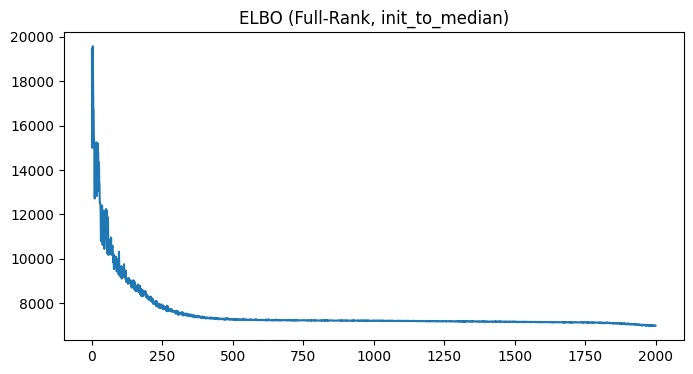

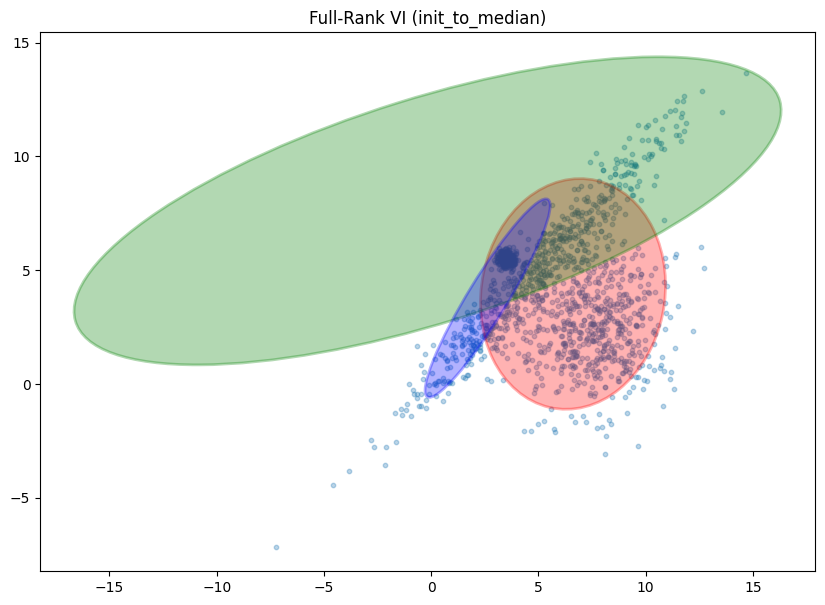

Step 0, ELBO: 10208.27
Step 500, ELBO: 6259.35
Step 1000, ELBO: 6050.45
Step 1500, ELBO: 6055.39
VI finished in 20.14 seconds


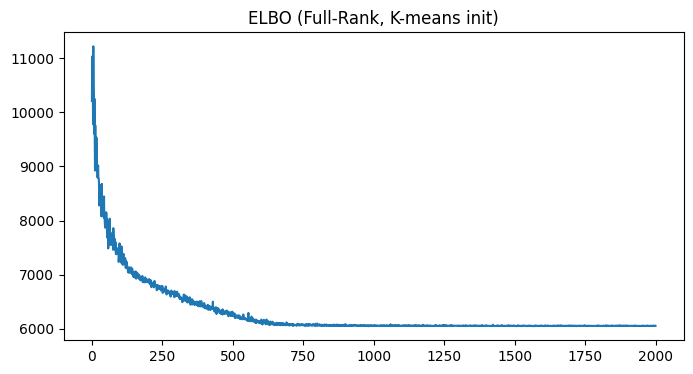

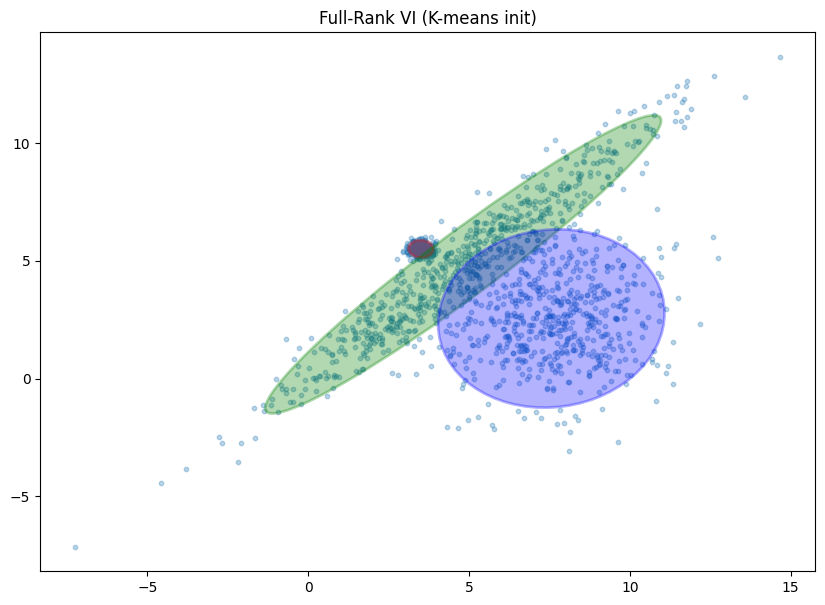

In [ ]:
# init_to_median
guide_fr = AutoMultivariateNormal(pyro.poutine.block(model_fr, hide=["obs"]),
                                  init_loc_fn=init_to_median)
svi_fr, loss_fr = run_svi(model_fr, guide_fr, data_2d)

plt.figure(figsize=(8,4))
plt.plot(loss_fr)
plt.title("ELBO (Full-Rank, init_to_median)")
plt.show()

locs_fr, cov_fr, w_fr = extract_params_fr(guide_fr, data_2d)

plt.figure(figsize=(10,7))
plt.scatter(data_2d[:,0], data_2d[:,1], s=10, alpha=0.3)
for k in range(K):
    plot_ellipses(plt.gca(), locs_fr[k], cov_fr[k], color=colors[k], alpha=0.3)
plt.title("Full-Rank VI (init_to_median)")
plt.show()

# K-means инициализация
def init_to_kmeans_fr(site):
    if site["name"] == "locs":
        km = KMeans(n_clusters=K, random_state=42).fit(data_2d.numpy())
        return torch.tensor(km.cluster_centers_, dtype=torch.float32)
    return init_to_median(site)

guide_fr_km = AutoMultivariateNormal(pyro.poutine.block(model_fr, hide=["obs"]),
                                     init_loc_fn=init_to_kmeans_fr)
svi_fr_km, loss_fr_km = run_svi(model_fr, guide_fr_km, data_2d)

plt.figure(figsize=(8,4))
plt.plot(loss_fr_km)
plt.title("ELBO (Full-Rank, K-means init)")
plt.show()

locs_fr_km, cov_fr_km, w_fr_km = extract_params_fr(guide_fr_km, data_2d)

plt.figure(figsize=(10,7))
plt.scatter(data_2d[:,0], data_2d[:,1], s=10, alpha=0.3)
for k in range(K):
    plot_ellipses(plt.gca(), locs_fr_km[k], cov_fr_km[k], color=colors[k], alpha=0.3)
plt.title("Full-Rank VI (K-means init)")
plt.show()

Раздел 2 – MCMC (NUTS)

Вывод: MCMC способен точно аппроксимировать апостериорное распределение без предположений о его форме, но требует больше времени и тщательной диагностики. Это демонстрирует сильную сторону MCMC (точность) и слабую (вычислительную сложность).

# warmup 20
Кластер Синий: 
1) Маленький и вытянутый - плохо 
2) Теряет точки 
3) Втянут в зеленый - очень плохо
Кластер Красный: 
1) Втянут в зеленый - плохо!
2) Маленький - хорошо
Кластер Зеленый: 
1) Стал очень большим - плохо
2) Проглотил части остальных - плохо

Итог: 20 итераций прогрева КАТАСТРОФИЧЕСКИ МАЛО и все пошло плохо

# warmup 100

Кластер Синий: 
Все хоршо!

Красный и зеленый поменялись местами???

Итог: Все хоршо, но 2 кластера поменялись местами. Возможно исправит выравнивания меток 

Sample: 100%|██████████| 320/320 [00:20, 15.90it/s, step size=5.51e-02, acc. prob=0.110]


MCMC (warmup=20) finished in 20.14 seconds


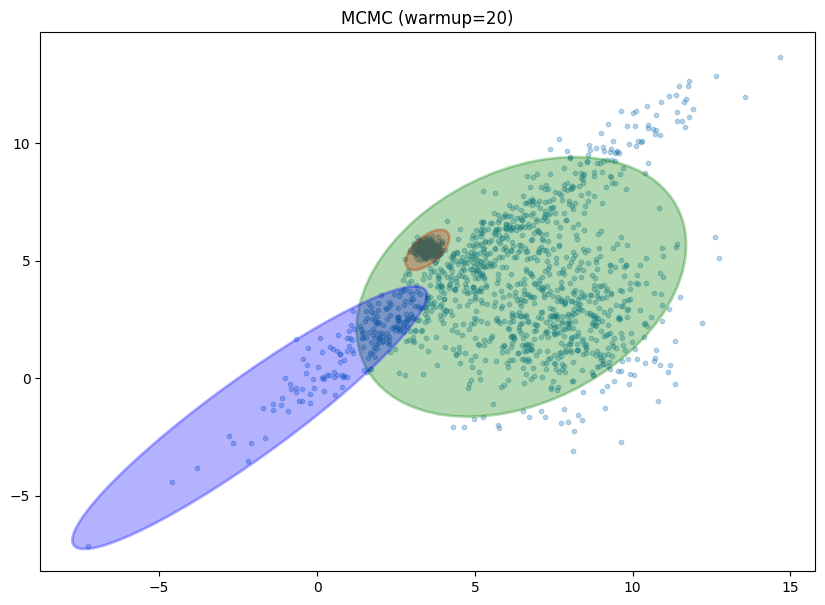

Sample: 100%|██████████| 400/400 [05:26,  1.22it/s, step size=4.89e-03, acc. prob=0.930]


MCMC (warmup=100) finished in 326.87 seconds


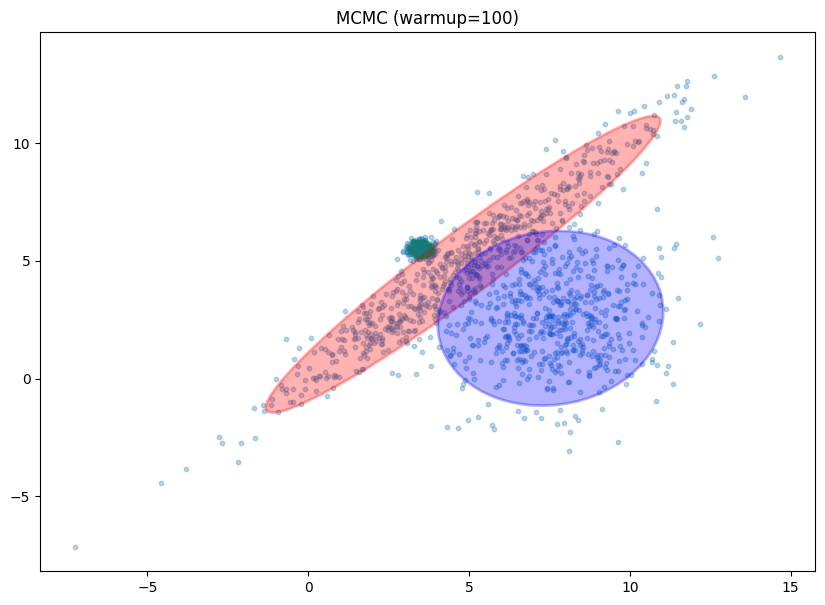

In [17]:
def run_mcmc(model, data, warmup_steps, num_samples=300, num_chains=1):
    nuts_kernel = NUTS(model, init_strategy=init_to_median)
    mcmc = MCMC(nuts_kernel, num_samples=num_samples,
                warmup_steps=warmup_steps, num_chains=num_chains)
    start = time.time()
    mcmc.run(data)
    elapsed = time.time() - start
    print(f"MCMC (warmup={warmup_steps}) finished in {elapsed:.2f} seconds")
    return mcmc, elapsed

# MCMC с warmup=20
mcmc_w20, time_w20 = run_mcmc(model_fr, data_2d, warmup_steps=20)
samples_w20 = mcmc_w20.get_samples()
locs_w20 = samples_w20["locs"].mean(0)
cov_w20 = torch.empty(K, 2, 2)
for k in range(K):
    L = torch.matmul(torch.diag_embed(samples_w20["scales"][:, k, :]), samples_w20["corr_cholesky"][:, k, :, :])
    cov_w20[k] = (L @ L.transpose(-1, -2)).mean(0)

plt.figure(figsize=(10,7))
plt.scatter(data_2d[:,0], data_2d[:,1], s=10, alpha=0.3)
for k in range(K):
    plot_ellipses(plt.gca(), locs_w20[k], cov_w20[k], color=colors[k], alpha=0.3)
plt.title("MCMC (warmup=20)")
plt.show()

# MCMC с warmup=100
mcmc_w100, time_w100 = run_mcmc(model_fr, data_2d, warmup_steps=100)
samples_w100 = mcmc_w100.get_samples()
locs_w100 = samples_w100["locs"].mean(0)
cov_w100 = torch.empty(K, 2, 2)
for k in range(K):
    L = torch.matmul(torch.diag_embed(samples_w100["scales"][:, k, :]), samples_w100["corr_cholesky"][:, k, :, :])
    cov_w100[k] = (L @ L.transpose(-1, -2)).mean(0)

plt.figure(figsize=(10,7))
plt.scatter(data_2d[:,0], data_2d[:,1], s=10, alpha=0.3)
for k in range(K):
    plot_ellipses(plt.gca(), locs_w100[k], cov_w100[k], color=colors[k], alpha=0.3)
plt.title("MCMC (warmup=100)")
plt.show()

MCMC warmup=20:
locs[0]: mean=2.612, std=3.581, CI90=(-2.230, 6.550)
locs[1]: mean=2.551, std=3.089, CI90=(-1.658, 5.514)
scales[0]: mean=1.884, std=1.181, CI90=(0.185, 2.860)
scales[1]: mean=1.929, std=1.219, CI90=(0.189, 2.992)

MCMC warmup=100:
locs[0]: mean=5.285, std=1.681, CI90=(3.491, 7.633)
locs[1]: mean=4.308, std=1.264, CI90=(2.468, 5.513)
scales[0]: mean=1.671, std=1.175, CI90=(0.187, 3.151)
scales[1]: mean=1.730, std=1.215, CI90=(0.177, 3.238)


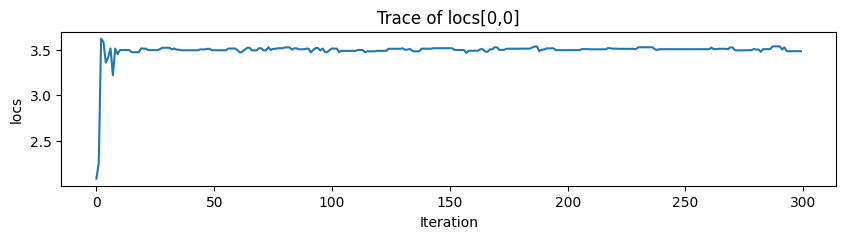

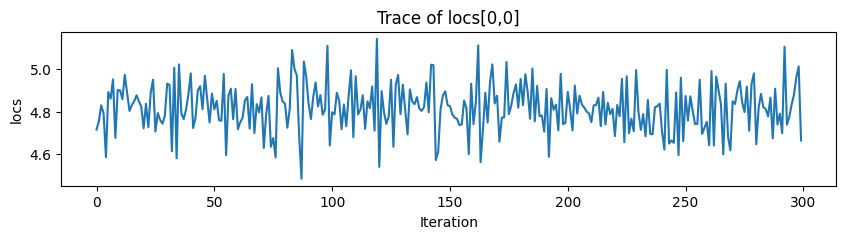

In [28]:
import pandas as pd

def pyro_summary(mcmc, var_names=["locs", "scales"]):
    samples = mcmc.get_samples()
    for name in var_names:
        data = samples[name].reshape(-1, samples[name].shape[-1])
        for dim in range(data.shape[1]):
            s = data[:, dim]
            print(f"{name}[{dim}]: mean={s.mean():.3f}, std={s.std():.3f}, "
                  f"CI90=({s.quantile(0.05):.3f}, {s.quantile(0.95):.3f})")

print("MCMC warmup=20:")
pyro_summary(mcmc_w20)

print("\nMCMC warmup=100:")
pyro_summary(mcmc_w100)

# Простейший trace plot без arviz
def pyro_trace_plot(samples, name, k_idx=0, d_idx=0):
    vals = samples[name][:, k_idx, d_idx].numpy()
    plt.figure(figsize=(10,2))
    plt.plot(vals)
    plt.title(f"Trace of {name}[{k_idx},{d_idx}]")
    plt.xlabel("Iteration")
    plt.ylabel(name)
    plt.show()

# Покажем только первый компонент и первую координату локаций
pyro_trace_plot(samples_w20, "locs", k_idx=0, d_idx=0)
pyro_trace_plot(samples_w100, "locs", k_idx=0, d_idx=0)

Раздел 3 – Разреживающее априори (K=10, α=0.1)

Параметр концентрации α = 0.1 < 1 делает априорное распределение Дирихле «сконцентрированным» на гранях симплекса.

Step 0, ELBO: 12097.74
Step 500, ELBO: 6334.78
Step 1000, ELBO: 6139.15
Step 1500, ELBO: 6119.89
VI finished in 24.63 seconds


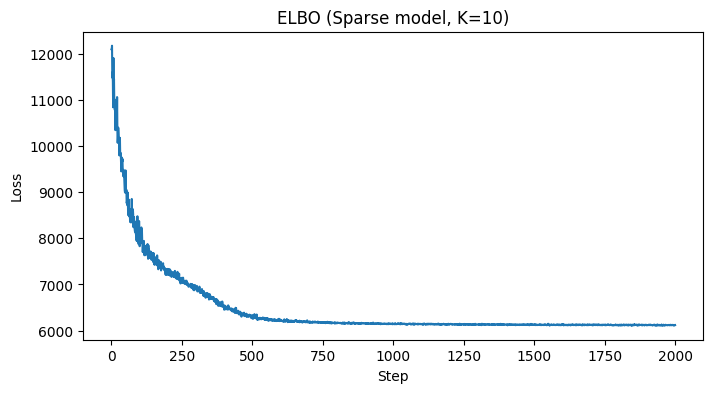

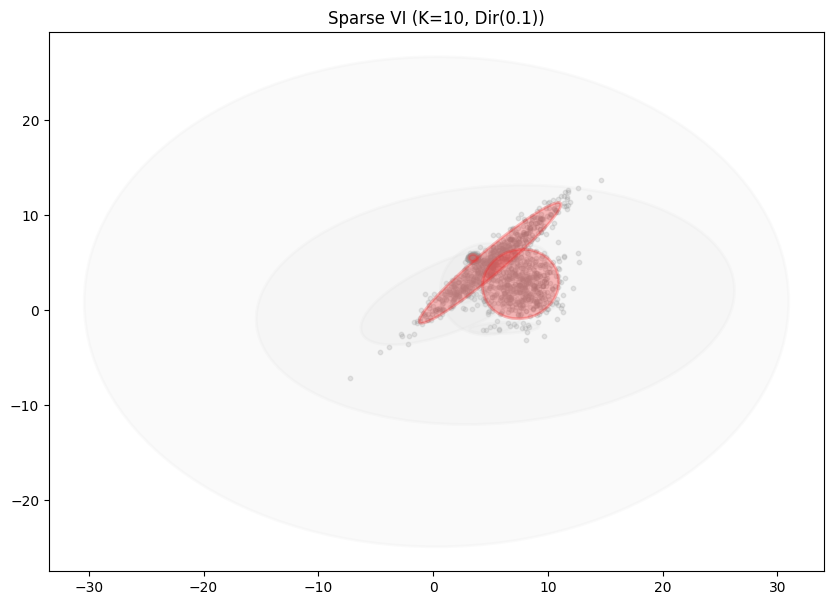

Компонент с весом > 0.05: 3 (из 10)
Веса компонент: [0.024 0.016 0.006 0.009 0.005 0.196 0.357 0.384 0.002 0.001]


In [31]:
def model_sparse(data, K=10):
    D = data.shape[1]
    weights = pyro.sample("weights", dist.Dirichlet(0.1 * torch.ones(K)))
    with pyro.plate("components", K):
        locs = pyro.sample("locs", dist.Normal(torch.zeros(D), 10.0).to_event(1))
        scales = pyro.sample("scales", dist.LogNormal(torch.zeros(D), 2.0).to_event(1)) + 0.01
        corr_cholesky = pyro.sample("corr_cholesky", dist.LKJCholesky(D, concentration=1.0))
        L = torch.matmul(torch.diag_embed(scales), corr_cholesky)
    with pyro.plate("data", len(data)):
        pyro.sample("obs", dist.MixtureSameFamily(
            dist.Categorical(weights),
            dist.MultivariateNormal(locs, scale_tril=L)
        ), obs=data)

# Full‑Rank VI со sparse-моделью
guide_sp = AutoMultivariateNormal(pyro.poutine.block(model_sparse, hide=["obs"]),
                                  init_loc_fn=init_to_median)
svi_sp, loss_sp = run_svi(model_sparse, guide_sp, data_2d)

plt.figure(figsize=(8,4))
plt.plot(loss_sp)
plt.title("ELBO (Sparse model, K=10)")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.show()

# Извлечение параметров
predictive_sp = Predictive(model_sparse, guide=guide_sp, num_samples=200,
                           return_sites=("locs", "scales", "corr_cholesky", "weights"))
with torch.no_grad():
    samples_sp = predictive_sp(data_2d)

# Усредним и приведём к правильной размерности
locs_sp = samples_sp["locs"].mean(0)          # [K, D]
weights_sp = samples_sp["weights"].mean(0).squeeze()  # [K] – обязательно сжимаем
K_sp = 10
cov_sp = torch.zeros(K_sp, 2, 2)
for s in range(200):
    L = torch.matmul(torch.diag_embed(samples_sp["scales"][s]), 
                     samples_sp["corr_cholesky"][s])
    cov_sp += (L @ L.transpose(-1, -2))
cov_sp /= 200

# Визуализация с раскраской по весам
fig, ax = plt.subplots(figsize=(10,7))
ax.scatter(data_2d[:,0], data_2d[:,1], s=10, alpha=0.2, color='gray')
for k in range(K_sp):
    # Теперь weights_sp[k] – одномерный тензор с одним элементом
    if weights_sp[k].item() > 0.05:
        plot_ellipses(ax, locs_sp[k], cov_sp[k], color='red', alpha=0.3)
    else:
        plot_ellipses(ax, locs_sp[k], cov_sp[k], color='lightgray', alpha=0.1)
ax.set_title("Sparse VI (K=10, Dir(0.1))")
plt.show()

# Вывод значимых компонент
significant = (weights_sp > 0.05).sum().item()
print(f"Компонент с весом > 0.05: {significant} (из 10)")
print("Веса компонент:", weights_sp.detach().cpu().numpy().round(3))

# Ответы на теоретические вопросы

# Почему VI работает на порядки быстрее MCMC на больших данных, но может давать смещенную оценку дисперсии?

Заметим, что SVI делает 2000 градиентных шагов и завершается очень быстро, тогда как MCMC требует гораздо больше времени (даже при 300 сэмплах). Это хорошо вижно из скорости исполнения в нашем задании (40 против 350 секунд на выполнение).

Причина:  VI оптимизирует ELBO, используя быстрый градиентный спуск. MCMC же последовательно генерирует сэмплы, и требует вычисления логарифма плотности на всех данных.

# Является ли использование K-means для инициализации байесовской модели "честным" подходом?

Да, является. K-means использовали, чтобы задать начальное приближение для алгоритма оптимизации. При этом ELBO не изменяется. 

# Как разреживающее априорное распределение Дирихле (sparsity prior) может помочь в автоматическом определении количества кластеров?

По заданию мы ставим K=10, но α=0.1. После испольнения мы видим, что только несколько компонент имеют вес > 0.05, остальные практически нулевые, это автоматически определяет эффективное число кластеров. При использовании MCMC, проблема label switching вызвала бы сильное замедление, VI легко сходится к одной из мод, игнорируя лишние компоненты. Он не тратит время на исследование всех перестановок меток 

Личный итог

Когда использовать VI:
1) Большие данные
2) Нужно быстрое решение
3) Важна скорость, а не точная оценка неопределённости

Когда использовать MCMC:
1) Маленькие/средние данные
2) Нужна точная оценка неопределённости
3) Сложная модель
